# Environment-dependent tropical-cyclone genesis rate
## 1° gridded Poisson model interpreted as a discretized inhomogeneous Poisson point process

This notebook builds a first-generation replacement for:

**phase-conditioned basin frequency → month sampling → empirical/GPI genesis map**

with one fitted environmental rate surface:

\[
N_{iym}\sim \mathrm{Poisson}(\mu_{iym}),\qquad
\mu_{iym}=E_{iym}\lambda_{iym}
\]

and

\[
\log \lambda_{iym}
=
\alpha
+\mathrm{month\ effect}
+\beta_{PI}PI
+\beta_{RH}RH
+\beta_{VWS}VWS
+\beta_{\eta}\eta.
\]

Here \(i\) is a 1° genesis cell, \(y\) the year and \(m\) the month.

The exposure \(E\) explicitly accounts for:

- spherical cell area;
- the fraction of the cell that is eligible ocean;
- month duration.

The fitted expected cell counts \(\mu_i\) simultaneously determine:

1. basin/month storm frequency: \(\Lambda=\sum_i\mu_i\);
2. genesis-location probabilities: \(p_i=\mu_i/\Lambda\).

After a 1° cell is selected, the exact genesis location is sampled uniformly over the **eligible ocean part** of the cell using a 0.1° fine mask. This keeps the downscaling deliberately simple while preventing land genesis.

## 0. Assumptions and inputs

This notebook deliberately starts with one basin (e.g. North Atlantic) and one simple Poisson specification.

Expected inputs:

1. `env_native`: monthly `xarray.Dataset` containing at least:
   - `pi` : thermodynamic potential intensity [m/s]
   - `rh600` : relative humidity at 600 hPa [% or fraction, but consistent]
   - `vws` : 850–200 hPa vertical wind shear magnitude [m/s]
   - `abs_vort850` : absolute vorticity magnitude [s-1]

2. `genesis`: a pandas DataFrame with one row per historical genesis event:
   - `storm_id`
   - `time`
   - `lat`
   - `lon`

The genesis definition must match the simulator target. If the simulator starts storms when they first reach tropical-storm intensity, use that same definition here.

3. `land_gdf`: a reasonably high-resolution land polygon GeoDataFrame (Natural Earth 10m / GSHHG / existing project coastline).

4. `basin_polygon`: the valid basin-water domain. This is important because `~land` alone can leave inland water bodies eligible.

In [1]:
from __future__ import annotations

import calendar
import os
import sys
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely import box, contains_xy, union_all

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import poisson
import os
from datetime import date

## 1. Configuration

In [24]:
# Set this to the repository root. The notebook assumes the normal project layout:
# REPO_ROOT/
#   CODE/genesis_matrix.py
#   Land_ocean_masks/Land_ocean_mask_NA.txt
REPO_ROOT = os.path.dirname(os.getcwd())
sys.path.append(str(Path.cwd().parent))


import CODE.genesis_matrix as gm

# genesis_matrix.py currently derives __location__ from os.getcwd().
# Explicitly point it at the repository root so its existing mask loader is robust
# even if this notebook was launched from another directory.
gm.__location__ = str(REPO_ROOT)


ACTIVE_MONTHS = {
    "EP": (6, 7, 8, 9, 10, 11),
    "NA": (6, 7, 8, 9, 10, 11),
    "NI": (4, 5, 6, 9, 10, 11),
    "SI": (1, 2, 3, 4, 11, 12),
    "SP": (1, 2, 3, 4, 11, 12),
    "WP": (5, 6, 7, 8, 9, 10, 11),
}


@dataclass(frozen=True)
class GenesisConfig:
    basin: str = "NA"

    # Exposure scaling only changes the intercept and keeps coefficients readable.
    area_unit_km2: float = 100_000.0
    reference_month_days: float = 365.2425 / 12.0

    # Strict temporal holdout for the first experiment.
    first_test_year: int = 2016

    # Same native mask resolution already used by STORM.
    fine_res: float = 0.1

    active_months: tuple = (6, 7, 8, 9, 10, 11)
    lat_min, lat_max, lon_min, lon_max = gm.BOUNDARIES_BASINS(CFG.basin)


CFG = GenesisConfig()

lat0, lat1, lon0, lon1 = gm.BOUNDARIES_BASINS(CFG.basin)
ROWS = int(abs(lat1 - lat0))
COLS = int(abs(lon1 - lon0))

LAT2D, LON2D = gm.basin_cell_centers(CFG.basin, ROWS, COLS)
LAT = LAT2D[:, 0]  # north -> south, matching genesis_matrix.py
LON = LON2D[0, :]  # west -> east, 0..360 convention

print(CFG)
print(f"{CFG.basin}: {ROWS} x {COLS} 1-degree cells")
print(f"lat: {LAT[0]} -> {LAT[-1]}")
print(f"lon: {LON[0]} -> {LON[-1]}")

GenesisConfig(basin='NA', area_unit_km2=100000.0, reference_month_days=30.436875, first_test_year=2016, fine_res=0.1, active_months=(6, 7, 8, 9, 10, 11))
NA: 55 x 105 1-degree cells
lat: 59.5 -> 5.5
lon: 255.5 -> 359.5


### Get mask

In [3]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from geodatasets import get_path


land_gdf = geopandas.read_file(get_path("naturalearth.land"))

### Load STORMS

In [4]:
REPO_ROOT = os.path.dirname(os.getcwd())

year = np.load(os.path.join(REPO_ROOT, "YEARLIST_INTERP.npy"), allow_pickle=True).item()
lat = np.load(os.path.join(REPO_ROOT, "LATLIST_INTERP.npy"), allow_pickle=True).item()
lon = np.load(os.path.join(REPO_ROOT, "LONLIST_INTERP.npy"), allow_pickle=True).item()
pressure = np.load(os.path.join(REPO_ROOT, "PRESLIST_INTERP.npy"), allow_pickle=True).item()
month = np.load(os.path.join(REPO_ROOT, "MONTHLIST_INTERP.npy"), allow_pickle=True).item()

idx_clean = [idx for idx, i in enumerate(lat) if len(lat[i]) > 0]
year = [year[i] for i in idx_clean]
month = [month[i] for i in idx_clean]
lat = [lat[i] for i in idx_clean]
lon = [lon[i] for i in idx_clean]
pressure = [pressure[i] for i in idx_clean]


In [36]:
genesis = pd.DataFrame(
    {
        "stormid": idx_clean,
        "time": [date(int(year[i][0]), int(month[i][0]), 1) for i in range(len(idx_clean))],
        "latitude": [lat_i[0] for lat_i in lat],
        "longitude": [lon_i[0] for lon_i in lon],
    }
)

In [38]:
genesis_na = genesis.loc[(genesis["latitude"] > 0) & (genesis["longitude"] > 250),]

### Load nc files

In [125]:
import xarray as xr

VARS = ["T", "VWS", "RH600", "SST", "MSLP"]
VARS = ["MSLP", "VWS", "SST", "RH600"]
VARS_NAME = ["msl", "vws", "sst", "r"]


files = [xr.open_dataset(os.path.join(REPO_ROOT, f"Monthly_mean_{i}.nc")) for i in VARS]
env_native = xr.merge(files)

In [126]:
env_native

<xarray.Dataset> Size: 9GB
Dimensions:         (valid_time: 552, latitude: 721, longitude: 1440,
                     pressure_level: 1)
Coordinates:
    number          int64 8B 0
  * valid_time      (valid_time) datetime64[ns] 4kB 1980-01-01 ... 2025-12-01
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    expver          (valid_time) <U4 9kB '0001' '0001' '0001' ... '0001' '0001'
  * pressure_level  (pressure_level) float64 8B 600.0
Data variables:
    msl             (valid_time, latitude, longitude) float32 2GB ...
    vws             (valid_time, latitude, longitude) float32 2GB ...
    sst             (valid_time, latitude, longitude) float32 2GB ...
    r               (valid_time, pressure_level, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-21T21:10 GRIB to CDM+CF via cfgrib-0.9.1...

### Load npy files

In [113]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr


path_files = Path(
    "/home/mbaldacchino/data/SIENA-IH-STORM_1980_2025_VF/SIENA-IH-STORM/env_yearly"
)

# Files we actually need for the first genesis model.
NAME_MAP = {
    "VMAX_PI": "pi",  # thermodynamic PI maximum wind [m/s]
    "VWS": "vws",  # 850-200 hPa shear [m/s]
    "RH600": "rh600",  # relative humidity
    "VORT850": "vort850",  # relative vorticity [s-1]
}

START_YEAR = 1980
END_YEAR = 2024

def parse_env_filename(path):
    """
    Parse:
        VWS_2000_6.npy
        VMAX_PI_2000_6.npy
        VORT850_2018_10.npy

    Returns:
        variable, year, month
    """
    name, year, month = path.stem.rsplit("_", 2)

    return name, int(year), int(month)

In [134]:
def load_environment_dataset(
    path_files,
    name_map,
    start_year=1980,
    end_year=2024,
):
    path_files = Path(path_files)

    # Your arrays are the global 0.25° fields used elsewhere in the repo:
    # 721 latitudes: 90 -> -90
    # 1440 longitudes: 0 -> 359.75
    lat = np.linspace(90.0, -90.0, 721)
    lon = np.arange(1440) * 0.25

    variables = {}

    for file_name, xr_name in name_map.items():
        records = []

        for file in path_files.glob(f"{file_name}_*.npy"):
            name, year, month = parse_env_filename(file)

            if name != file_name:
                continue

            if not (start_year <= year <= end_year):
                continue

            records.append((year, month, file))

        records.sort(key=lambda x: (x[0], x[1]))

        if not records:
            raise FileNotFoundError(f"No files found for {file_name}")

        arrays = []
        times = []

        for year, month, file in records:
            arr = np.load(file)

            if arr.shape != (721, 1440):
                raise ValueError(f"{file.name}: expected (721, 1440), got {arr.shape}")

            arrays.append(arr)

            times.append(pd.Timestamp(year=year, month=month, day=1))

        variables[xr_name] = xr.DataArray(
            np.stack(arrays, axis=0),
            dims=("valid_time", "latitude", "longitude"),
            coords={
                "valid_time": pd.DatetimeIndex(times),
                "latitude": lat,
                "longitude": lon,
            },
            name=xr_name,
        )

    return xr.Dataset(variables)


In [135]:
env_native = load_environment_dataset(
    path_files=path_files,
    name_map=NAME_MAP,
    start_year=START_YEAR,
    end_year=END_YEAR,
)

env_native


<xarray.Dataset> Size: 9GB
Dimensions:     (valid_time: 540, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 1980-01-01 ... 2024-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    pi          (valid_time, latitude, longitude) float32 2GB nan nan ... nan
    vws         (valid_time, latitude, longitude) float32 2GB 0.0001297 ... 0...
    rh600       (valid_time, latitude, longitude) float32 2GB 72.23 ... 79.06
    vort850     (valid_time, latitude, longitude) float32 2GB nan nan ... nan

## 2. Grid definition and exact spherical cell areas

A 1° latitude-longitude cell does not have the same area at 10°N and 50°N.
The exposure therefore uses spherical rectangle area rather than a constant cell area.

In [71]:
EARTH_RADIUS_KM = 6371.0088


def spherical_1deg_area_km2(lat_center):
    """Exact spherical area of a 1° x 1° lat/lon cell centered at lat_center."""
    lat_lo = np.deg2rad(np.asarray(lat_center) - 0.5)
    lat_hi = np.deg2rad(np.asarray(lat_center) + 0.5)
    dlon = np.deg2rad(1.0)
    return EARTH_RADIUS_KM**2 * dlon * (np.sin(lat_hi) - np.sin(lat_lo))


def build_existing_storm_exposure(
    basin: str,
    repo_root: Path,
) -> xr.Dataset:
    lat0, lat1, lon0, lon1 = gm.BOUNDARIES_BASINS(basin)
    rows = int(abs(lat1 - lat0))
    cols = int(abs(lon1 - lon0))

    # Existing authoritative 1° genesis-validity mask.
    ocean_valid = gm._genesis_ocean_mask_1deg(basin, (rows, cols))

    # Recover fractional ocean coverage from the exact same 0.1° mask.
    mask_path = os.path.join(repo_root, f"Land_ocean_masks/Land_ocean_mask_{basin}.txt")
    land10 = np.loadtxt(mask_path)

    # Same endpoint handling as _genesis_ocean_mask_1deg.
    land10 = land10[: rows * 10, : cols * 10]
    land_fraction = land10.reshape(rows, 10, cols, 10).mean(axis=(1, 3))
    ocean_fraction_raw = 1.0 - land_fraction

    # Preserve the exact existing genesis admissibility rule, including NA/EP split.
    eligible_fraction = np.where(ocean_valid, ocean_fraction_raw, 0.0)

    LAT2D, LON2D = gm.basin_cell_centers(basin, rows, cols)
    lat = LAT2D[:, 0]
    lon = LON2D[0, :]

    area_lat = spherical_1deg_area_km2(lat)
    cell_area = np.broadcast_to(area_lat[:, None], (rows, cols)).copy()
    eligible_area = cell_area * eligible_fraction

    return xr.Dataset(
        {
            "ocean_valid": (("latitude", "longitude"), ocean_valid),
            "raw_ocean_fraction": (("latitude", "longitude"), ocean_fraction_raw),
            "eligible_fraction": (("latitude", "longitude"), eligible_fraction),
            "cell_area_km2": (("latitude", "longitude"), cell_area),
            "eligible_area_km2": (("latitude", "longitude"), eligible_area),
        },
        coords={"latitude": lat, "longitude": lon},
    )


coarse_exposure = build_existing_storm_exposure(CFG.basin, REPO_ROOT)
coarse_exposure


<xarray.Dataset> Size: 192kB
Dimensions:             (latitude: 55, longitude: 105)
Coordinates:
  * latitude            (latitude) float64 440B 59.5 58.5 57.5 ... 7.5 6.5 5.5
  * longitude           (longitude) float64 840B 255.5 256.5 ... 358.5 359.5
Data variables:
    ocean_valid         (latitude, longitude) bool 6kB False False ... False
    raw_ocean_fraction  (latitude, longitude) float64 46kB 0.0 0.0 ... 0.03 0.34
    eligible_fraction   (latitude, longitude) float64 46kB 0.0 0.0 ... 0.0 0.0
    cell_area_km2       (latitude, longitude) float64 46kB 6.275e+03 ... 1.23...
    eligible_area_km2   (latitude, longitude) float64 46kB 0.0 0.0 ... 0.0 0.0

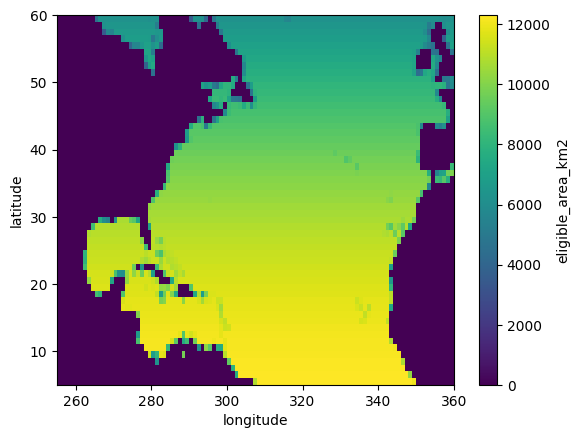

In [72]:
coarse_exposure.eligible_area_km2.plot()

## 3. Inspect the existing mask before modelling

Three fields are useful:

- `ocean_valid`: exactly what `_genesis_ocean_mask_1deg()` currently allows;
- `raw_ocean_fraction`: fractional ocean coverage from the underlying 0.1° mask;
- `eligible_fraction`: `raw_ocean_fraction` where the existing 1° rule allows genesis, otherwise 0.

This intentionally does **not** introduce a new coastline or a new basin polygon.

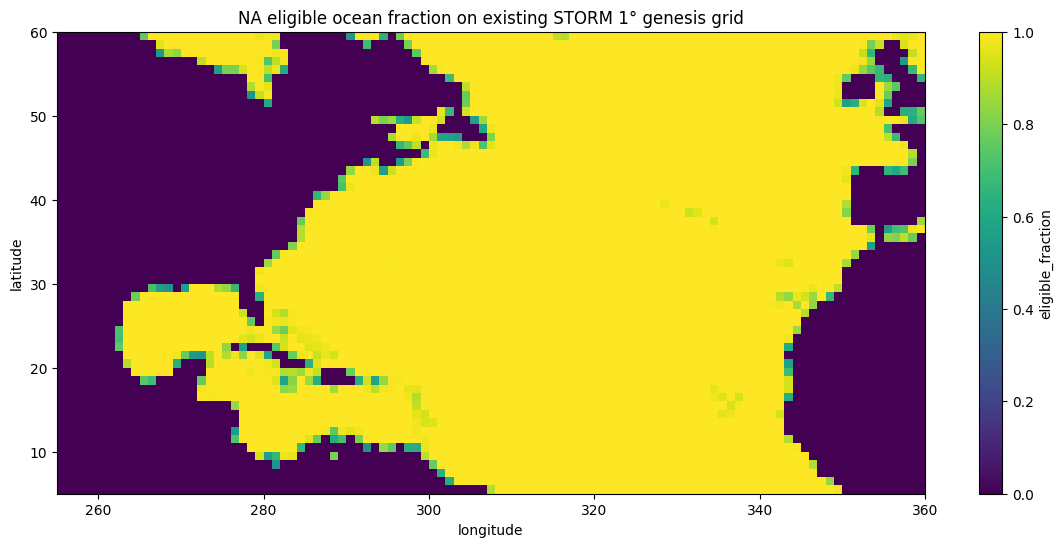

Eligible 1° cells: 3677 / 5775


In [73]:
fig, ax = plt.subplots(figsize=(14, 6))
coarse_exposure["eligible_fraction"].plot(ax=ax)
ax.set_title(f"{CFG.basin} eligible ocean fraction on existing STORM 1° genesis grid")
plt.show()

print(
    "Eligible 1° cells:",
    int(coarse_exposure["ocean_valid"].sum()),
    "/",
    ROWS * COLS,
)


### Why retain ocean fraction if the existing helper is binary?

The existing helper is ideal for **admissibility** and consistency with the simulator.
For the Poisson model, however, the exposure offset represents available ocean area.

A coastal cell that is 55% ocean and passes the existing `< 50% land` rule should not
contribute the same physical exposure as a 100% ocean cell. Therefore:

`ocean_valid` decides whether the cell exists in the genesis domain, while
`eligible_area_km2` determines how much exposure it contributes.

In [74]:
# Sanity checks: rejected cells must have zero exposure; accepted cells must have >0.
assert bool(
    (
        coarse_exposure["eligible_area_km2"].where(~coarse_exposure["ocean_valid"], 0)
        == 0
    ).all()
)

accepted = coarse_exposure["ocean_valid"].values
assert np.all(coarse_exposure["eligible_area_km2"].values[accepted] > 0)

coarse_exposure[
    ["ocean_valid", "raw_ocean_fraction", "eligible_fraction", "eligible_area_km2"]
]


<xarray.Dataset> Size: 146kB
Dimensions:             (latitude: 55, longitude: 105)
Coordinates:
  * latitude            (latitude) float64 440B 59.5 58.5 57.5 ... 7.5 6.5 5.5
  * longitude           (longitude) float64 840B 255.5 256.5 ... 358.5 359.5
Data variables:
    ocean_valid         (latitude, longitude) bool 6kB False False ... False
    raw_ocean_fraction  (latitude, longitude) float64 46kB 0.0 0.0 ... 0.03 0.34
    eligible_fraction   (latitude, longitude) float64 46kB 0.0 0.0 ... 0.0 0.0
    eligible_area_km2   (latitude, longitude) float64 46kB 0.0 0.0 ... 0.0 0.0

### Important consistency point

Do **not** add another `MIN_ELIGIBLE_FRACTION` threshold in the notebook.
`_genesis_ocean_mask_1deg()` already defines the existing STORM threshold:

```python
landfrac < 0.5
```

Adding a second threshold would silently create a different genesis domain.

In [15]:
# The existing helper is the only 1° admissibility threshold.
# No additional coastal-cell cutoff is applied here.
assert coarse_exposure["ocean_valid"].dtype == bool


## 4. Put environmental fields on the exact existing STORM 1° grid

Keep the project's 0–360° longitude convention.

The target coordinates come directly from `gm.basin_cell_centers()`, so the
environmental arrays, observed genesis counts, existing masks, and simulated
genesis probabilities all use the same row/column convention.

In [136]:
# FEATURES = ["pi", "rh600", "vws", "abs_vort850"]


def normalize_lon_360(ds: xr.Dataset, lon_name: str = "longitude") -> xr.Dataset:
    lon_new = ds[lon_name] % 360
    return ds.assign_coords({lon_name: lon_new}).sortby(lon_name)


def standardize_month_time(ds: xr.Dataset) -> xr.Dataset:
    t = pd.DatetimeIndex(ds.valid_time.values).to_period("M").to_timestamp()
    return ds.assign_coords(valid_time=t)


def to_existing_storm_grid(ds: xr.Dataset, cfg: GenesisConfig) -> xr.Dataset:
    ds = normalize_lon_360(ds)
    ds = standardize_month_time(ds)

    # xarray interpolation is safest with monotonic source coordinates.
    ds = ds.sortby("latitude").sortby("longitude")

    # Target latitude is intentionally north->south to match genesis_matrix.py.
    out = ds.interp(latitude=LAT, longitude=LON)
    out = out.sel(valid_time=out.valid_time.dt.month.isin(ACTIVE_MONTHS[cfg.basin]))

    return out


# Example if the fields are already suitable for direct interpolation:
env_1deg = to_existing_storm_grid(env_native, CFG)[
    list(NAME_MAP.values())
]#[VARS_NAME]
#
# If your 0.25° preprocessing already has a preferred area/ocean-weighted
# 0.25° -> 1° aggregation, use that instead, but end on exactly LAT/LON above.


### Recommended 0.25° → 1° aggregation

If your ERA5 fields are on a 0.25° grid aligned with the 1° cells, prefer an ocean-weighted block mean rather than interpolation. The exact implementation should reuse the land/basin mask already produced in your preprocessing pipeline.

Conceptually, for variable \(X\):

\[
X_{1^\circ}
=

rac{\sum_{j\in cell} X_j\,A_j\,I_{ocean,j}}
{\sum_{j\in cell} A_j\,I_{ocean,j}}.
\]

Do this consistently for ERA5 and any forecast fields that need regridding.

## 5. Historical genesis events

`genesis` should already contain exactly one row per storm under the definition you want the synthetic model to reproduce.

Recommended for compatibility with a STORM-like simulator:

- keep tropical/subtropical nature according to a fixed documented rule;
- identify the first fix at which the storm reaches the simulator's minimum wind threshold;
- use a single wind convention consistently;
- assign that time/location as the genesis event.

Do **not** fit a model to disturbance genesis if your simulator starts at tropical-storm genesis.

In [137]:
def normalize_lon_values(lon_values):
    """Use the same 0..360 convention as the STORM basin definitions."""
    return np.asarray(lon_values, dtype=float) % 360


def prepare_genesis_events(genesis: pd.DataFrame, cfg: GenesisConfig) -> pd.DataFrame:
    lat0, lat1, lon0, lon1 = gm.BOUNDARIES_BASINS(cfg.basin)

    g = genesis.copy()
    g["time"] = pd.to_datetime(g["time"])
    g["time_month"] = g["time"].dt.to_period("M").dt.to_timestamp()
    g["year"] = g["time"].dt.year
    g["month"] = g["time"].dt.month
    g["longitude"] = normalize_lon_values(g["longitude"])

    g = g[
        g["month"].isin(ACTIVE_MONTHS[cfg.basin])
        & g["latitude"].ge(lat0)
        & g["latitude"].lt(lat1)
        & g["longitude"].ge(lon0)
        & g["longitude"].lt(lon1)
    ].copy()

    return g


genesis = prepare_genesis_events(genesis_na, CFG)

## 6. Assign observed genesis events to the existing 1° STORM cells

Rows are north-to-south and columns west-to-east, exactly as in
`basin_cell_centers()` and `_genesis_ocean_mask_1deg()`.

In [138]:
def assign_cells(df: pd.DataFrame, basin: str) -> pd.DataFrame:
    lat0, lat1, lon0, lon1 = gm.BOUNDARIES_BASINS(basin)
    rows = int(abs(lat1 - lat0))
    cols = int(abs(lon1 - lon0))

    out = df.copy()

    # Row 0 is [lat1-1, lat1), centered at lat1-0.5.
    ilat = np.floor(lat1 - out["latitude"].to_numpy()).astype(int)
    ilon = np.floor(out["longitude"].to_numpy() - lon0).astype(int)

    valid = (ilat >= 0) & (ilat < rows) & (ilon >= 0) & (ilon < cols)

    out = out.loc[valid].copy()
    out["ilat"] = ilat[valid]
    out["ilon"] = ilon[valid]
    out["cell_lat"] = LAT[out["ilat"].to_numpy()]
    out["cell_lon"] = LON[out["ilon"].to_numpy()]

    return out


genesis = assign_cells(genesis, CFG.basin)


### Critical land-mask audit

Any historical genesis point assigned to a cell with zero eligible ocean area indicates one of:

- a coastline mismatch;
- a basin-mask mismatch;
- a longitude convention problem;
- an inconsistent genesis definition;
- an actual preprocessing error.

Do not silently drop these points.

In [140]:
def audit_genesis_against_exposure(
    genesis_cells: pd.DataFrame,
    coarse_exposure: xr.Dataset,
) -> pd.DataFrame:
    eligible = coarse_exposure["eligible_area_km2"].values
    vals = eligible[
        genesis_cells["ilat"].to_numpy(),
        genesis_cells["ilon"].to_numpy(),
    ]

    bad = genesis_cells.loc[vals <= 0].copy()
    bad["eligible_area_km2"] = vals[vals <= 0]
    return bad

bad_genesis = audit_genesis_against_exposure(genesis, coarse_exposure)
display(bad_genesis)
assert bad_genesis.empty

,stormid,time,latitude,longitude,time_month,year,month,ilat,ilon,cell_lat,cell_lon,eligible_area_km2
27,45,1980-06-01,14.2,256.399994,1980-06-01,1980,6,45,1,14.5,256.5,0.0
39,62,1980-08-01,14.9,256.799988,1980-08-01,1980,8,45,1,14.5,256.5,0.0
52,81,1980-09-01,12.8,255.399994,1980-09-01,1980,9,47,0,12.5,255.5,0.0
102,159,1981-07-01,13.9,255.199997,1981-07-01,1981,7,46,0,13.5,255.5,0.0
138,206,1981-10-01,11.4,258.000000,1981-10-01,1981,10,48,3,11.5,258.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3748,4841,2025-06-01,13.4,259.899994,2025-06-01,2025,6,46,4,13.5,259.5,0.0
3755,4861,2025-08-01,13.8,261.799988,2025-08-01,2025,8,46,6,13.5,261.5,0.0
3761,4874,2025-09-01,16.0,260.899994,2025-09-01,2025,9,44,5,15.5,260.5,0.0
3763,4879,2025-09-01,14.4,260.600006,2025-09-01,2025,9,45,5,14.5,260.5,0.0


AssertionError: 

## 7. Build the cell-month modelling table

Every eligible 1° cell and every historical active-season month is one row.

The response is:

`genesis_count`

Most rows will be zero. That is expected and is **not** by itself evidence of zero inflation.

Exposure is:

\[
E_{iym}
=

rac{A^{eligible}_i}{100000\ km^2}
	imes

rac{days(m)}{30.44}.
\]

The scale constants only make the intercept readable.

In [141]:
def build_model_table(
    env_1deg: xr.Dataset,
    coarse_exposure: xr.Dataset,
    genesis_cells: pd.DataFrame,
    cfg: GenesisConfig,
) -> pd.DataFrame:
    missing = [v for v in list(NAME_MAP.values()) if v not in env_1deg]
    if missing:
        raise KeyError(f"Missing environmental variables: {missing}")

    env_df = env_1deg[list(NAME_MAP.values())].to_dataframe().reset_index()
    env_df["time"] = pd.to_datetime(env_df["valid_time"])
    env_df["year"] = env_df["time"].dt.year
    env_df["month"] = env_df["time"].dt.month

    exposure_df = (
        coarse_exposure[["ocean_valid", "eligible_area_km2", "eligible_fraction"]]
        .to_dataframe()
        .reset_index()
    )


    df = env_df.merge(exposure_df, on=["latitude", "longitude"], how="left")

    counts = (
        genesis_cells.groupby(["time_month", "cell_lat", "cell_lon"])
        .size()
        .rename("genesis_count")
        .reset_index()
        .rename(
            columns={
                "time_month": "time",
                "cell_lat": "latitude",
                "cell_lon": "longitude",
            }
        )
    )

    df = df.merge(counts, on=["time", "latitude", "longitude"], how="left")
    df["genesis_count"] = df["genesis_count"].fillna(0).astype(int)

    days = df["time"].dt.days_in_month.astype(float)
    df["exposure"] = (df["eligible_area_km2"] / cfg.area_unit_km2) * (
        days / cfg.reference_month_days
    )

    valid = (
        df["ocean_valid"].fillna(False)
        & (df["exposure"] > 0)
        & np.isfinite(df[list(NAME_MAP.values())]).all(axis=1)
    )

    df = df.loc[valid].copy()
    df["log_exposure"] = np.log(df["exposure"])

    return df


model_df = build_model_table(env_1deg, coarse_exposure, genesis, CFG)
model_df.head()


,valid_time,latitude,longitude,pi,vws,rh600,vort850,time,year,month,ocean_valid,eligible_area_km2,eligible_fraction,genesis_count,exposure,log_exposure
10,1980-06-01,59.5,265.5,6.508024,13.020576,53.784195,-0.000011,1980-06-01,1980,6,True,4706.475159,0.75,0,0.046389,-3.070688
11,1980-06-01,59.5,266.5,6.508024,12.764136,54.354507,-0.000005,1980-06-01,1980,6,True,6275.300212,1.00,0,0.061852,-2.783006
12,1980-06-01,59.5,267.5,6.508024,12.508019,54.739273,0.000002,1980-06-01,1980,6,True,6275.300212,1.00,0,0.061852,-2.783006
13,1980-06-01,59.5,268.5,6.508024,12.223591,53.342789,0.000006,1980-06-01,1980,6,True,6275.300212,1.00,0,0.061852,-2.783006
14,1980-06-01,59.5,269.5,6.508024,11.927732,51.104507,0.000008,1980-06-01,1980,6,True,6275.300212,1.00,0,0.061852,-2.783006


## 8. Basic data diagnostics

Before fitting:

- verify observed annual/monthly counts;
- inspect environmental ranges at genesis vs all eligible ocean cells;
- inspect predictor correlation;
- check that no one variable contains unit mistakes.

In [142]:
def summarize_training_data(df: pd.DataFrame):
    print(f"Rows: {len(df):,}")
    print(f"Observed genesis events: {df.genesis_count.sum():,}")
    print()
    print("Events by month:")
    print(df.groupby("month")["genesis_count"].sum())
    print()
    print("Feature summary:")
    print(df[list(NAME_MAP.values())].describe().T)
    print()
    print("Feature correlation:")
    print(df[list(NAME_MAP.values())].corr())

summarize_training_data(model_df)

Rows: 992,790
Observed genesis events: 549

Events by month:
month
6      39
7      53
8     151
9     195
10     82
11     29
Name: genesis_count, dtype: int64

Feature summary:
            count          mean        std       min        25%        50%  \
pi       992790.0  4.021495e+01  25.811589  0.000000  12.124573  48.950365   
vws      992790.0  1.333532e+01   6.716089  0.020568   8.303964  12.622635   
rh600    992790.0  4.415561e+01  13.045417  6.928823  35.424176  43.728331   
vort850  992790.0 -7.615994e-07   0.000010 -0.000130  -0.000007  -0.000002   

               75%        max  
pi       64.487785  83.835663  
vws      17.504128  44.049568  
rh600    52.012684  88.686066  
vort850   0.000005   0.000195  

Feature correlation:
               pi       vws     rh600   vort850
pi       1.000000 -0.142071  0.041827 -0.268514
vws     -0.142071  1.000000 -0.281301  0.017534
rh600    0.041827 -0.281301  1.000000  0.332054
vort850 -0.268514  0.017534  0.332054  1.000000


## 9. Temporal split: never split random grid rows

A random train/test split would leak the same years and monthly environments into both samples.

The first validation should hold out entire years.

In [143]:
def split_by_year(df: pd.DataFrame, first_test_year: int):
    train = df[df["year"] < first_test_year].copy()
    test = df[df["year"] >= first_test_year].copy()
    return train, test

train, test = split_by_year(model_df, CFG.first_test_year)

## 10. Standardize environmental predictors using training data only

This is mainly numerical conditioning and makes coefficient magnitudes easier to compare.

In [144]:
def fit_standardizer(train: pd.DataFrame, features: list[str]):
    params = {}
    for col in features:
        mu = train[col].mean()
        sd = train[col].std()
        if not np.isfinite(sd) or sd == 0:
            raise ValueError(f"Invalid standard deviation for {col}: {sd}")
        params[col] = (mu, sd)
    return params

def apply_standardizer(df: pd.DataFrame, params):
    out = df.copy()
    for col, (mu, sd) in params.items():
        out[f"z_{col}"] = (out[col] - mu) / sd
    return out

scaler = fit_standardizer(train, list(NAME_MAP.values()))
train = apply_standardizer(train, scaler)
test = apply_standardizer(test, scaler)

## 11. Fit two models

### Baseline M0
Seasonality only.

### Environmental M1
Seasonality + PI + RH + VWS + absolute vorticity.

For V1, month is categorical. This is transparent and handles unusual basin seasonal cycles without forcing a sinusoidal shape.

Later we can replace selected linear terms by physically motivated saturating functions or GAM splines.

In [145]:
list(NAME_MAP.values())

['pi', 'vws', 'rh600', 'vort850']

In [146]:
def fit_poisson_models(train: pd.DataFrame):
    baseline_formula = "genesis_count ~ C(month)"

    env_formula = (
        "genesis_count ~ C(month)"
        " + z_pi"
        " + z_vws"
        " + z_rh600"
        " + z_vort850"
    )

    m0 = smf.glm(
        baseline_formula,
        data=train,
        family=sm.families.Poisson(),
        offset=train["log_exposure"],
    ).fit()

    m1 = smf.glm(
        env_formula,
        data=train,
        family=sm.families.Poisson(),
        offset=train["log_exposure"],
    ).fit()

    return m0, m1

m0, m1 = fit_poisson_models(train)
print(m1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          genesis_count   No. Observations:               794232
Model:                            GLM   Df Residuals:                   794222
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3023.0
Date:                Thu, 24 Sep 2026   Deviance:                       5232.1
Time:                        16:50:38   Pearson chi2:                 6.24e+05
No. Iterations:                    24   Pseudo R-squ. (CS):           0.001039
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -7.6128      0.262    -29.

## 12. First model sanity checks

The expected physical signs are useful diagnostics, not hard constraints:

- PI: generally positive;
- RH: generally positive;
- VWS: generally negative;
- absolute vorticity: generally positive, potentially saturating.

A wrong sign does not automatically imply a bug because predictors are correlated. It should trigger:

- unit checks;
- correlation checks;
- univariate response plots;
- blocked-validation comparisons.

Also inspect Poisson dispersion, but judge overdispersion primarily at the **basin-month/year** level rather than from the enormous number of tiny cell means.

In [147]:
def pearson_dispersion(result) -> float:
    return float(np.sum(result.resid_pearson**2) / result.df_resid)

print("M0 dispersion:", pearson_dispersion(m0))
print("M1 dispersion:", pearson_dispersion(m1))

M0 dispersion: 0.8811406293381593
M1 dispersion: 0.7851713643942205


## 13. Held-out predictions

`statsmodels` returns the expected number of genesis events in each cell-month because the exposure offset is supplied at prediction time.

Therefore:

\[
\hat\Lambda_{ym} = \sum_i \hat\mu_{iym}
\]

is automatically the predicted basin-month frequency.

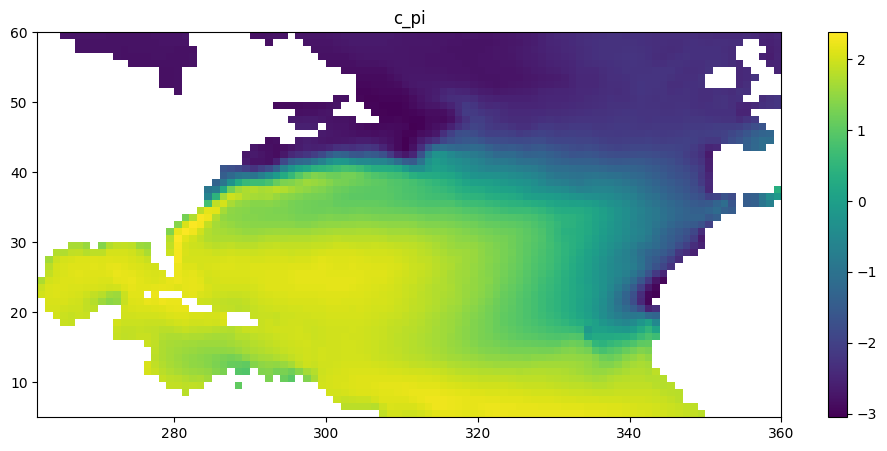

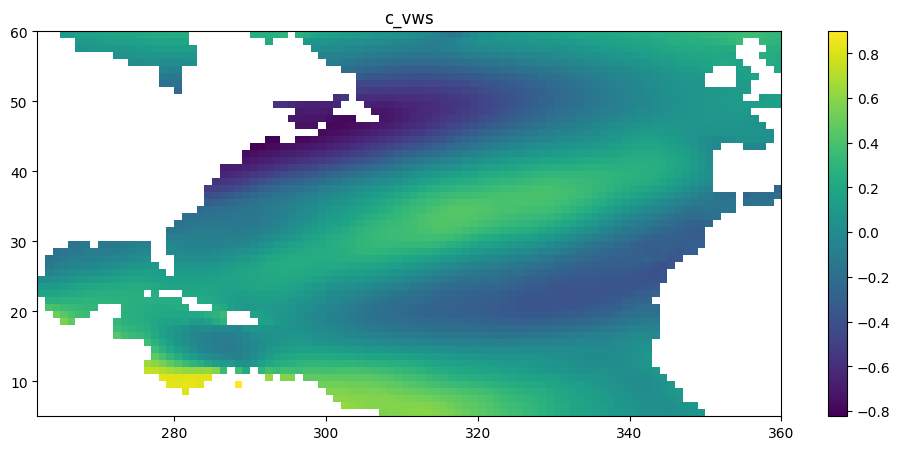

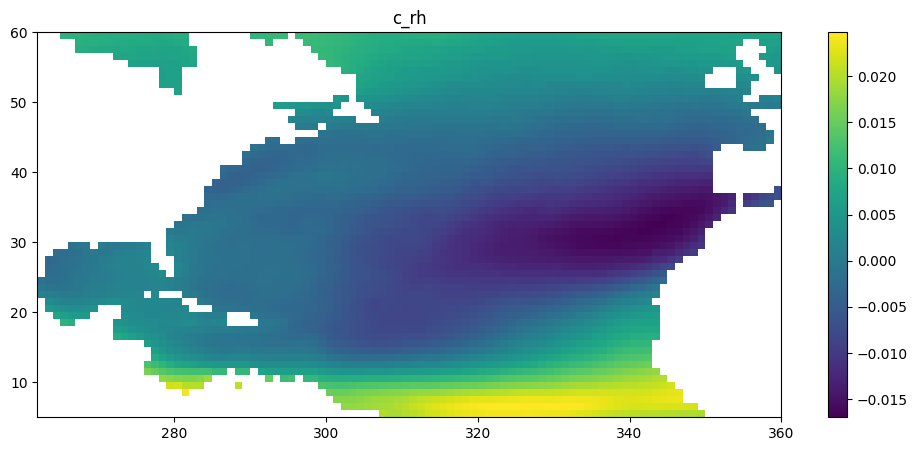

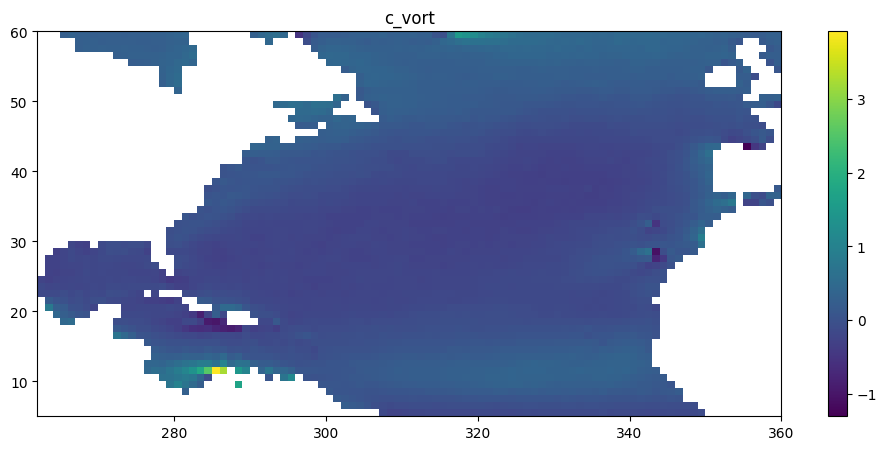

In [157]:
def add_predictions(df: pd.DataFrame, model, name: str) -> pd.DataFrame:
    out = df.copy()
    out[name] = model.predict(
        out,
        offset=out["log_exposure"],
    )
    return out

test = add_predictions(test, m0, "mu_m0")
test = add_predictions(test, m1, "mu_m1")

params = m1.params

for var in ["z_pi", "z_vws", "z_rh600", "z_vort850"]:
    test[f"contrib_{var}"] = params[var] * test[var]

diagnostic = (
    test.groupby(["latitude", "longitude"])
    .agg(
        expected=("mu_m1", "sum"),
        observed=("genesis_count", "sum"),
        z_pi=("z_pi", "mean"),
        z_vws=("z_vws", "mean"),
        z_rh600=("z_rh600", "mean"),
        z_vort850=("z_vort850", "mean"),
        c_pi=("contrib_z_pi", "mean"),
        c_vws=("contrib_z_vws", "mean"),
        c_rh=("contrib_z_rh600", "mean"),
        c_vort=("contrib_z_vort850", "mean"),
    )
    .reset_index()
)

diagnostic.sort_values("expected", ascending=False).head(30)

for col in ["c_pi", "c_vws", "c_rh", "c_vort"]:
    a = diagnostic.pivot(
        index="latitude",
        columns="longitude",
        values=col,
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.pcolormesh(
        a.columns,
        a.index,
        a.values,
        shading="auto",
    )
    ax.set_title(col)
    plt.colorbar(im, ax=ax)
    plt.show()

### Basin-month verification

The sum of independent Poisson variables is Poisson, so the aggregate predicted basin-month count is:

\[
N_{ym}\sim Pois(\Lambda_{ym}),
\qquad
\Lambda_{ym}=\sum_i\mu_{iym}.
\]

This gives a natural probabilistic score without any extra calibration layer.

In [149]:
def basin_month_scores(df: pd.DataFrame, mu_col: str) -> tuple[pd.DataFrame, dict]:
    agg = (
        df.groupby(["year", "month"], as_index=False)
        .agg(
            observed=("genesis_count", "sum"),
            lambda_pred=(mu_col, "sum"),
        )
    )

    agg["log_score"] = poisson.logpmf(
        agg["observed"],
        np.clip(agg["lambda_pred"], 1e-12, None),
    )

    metrics = {
        "mean_log_score": agg["log_score"].mean(),
        "bias": (agg["lambda_pred"] - agg["observed"]).mean(),
        "mae": np.abs(agg["lambda_pred"] - agg["observed"]).mean(),
        "rmse": np.sqrt(
            np.mean((agg["lambda_pred"] - agg["observed"]) ** 2)
        ),
    }
    return agg, metrics

agg0, score0 = basin_month_scores(test, "mu_m0")
agg1, score1 = basin_month_scores(test, "mu_m1")
print("M0:", score0)
print("M1:", score1)

M0: {'mean_log_score': np.float64(-1.920104697242123), 'bias': np.float64(-0.7453703703703808), 'mae': np.float64(1.3451646090535039), 'rmse': np.float64(1.7394227674105094)}
M1: {'mean_log_score': np.float64(-1.8329630060398345), 'bias': np.float64(-0.6486320833915685), 'mae': np.float64(1.264876929412208), 'rmse': np.float64(1.6259965111129313)}


### Spatial held-out log score

For the gridded point-process approximation, the cell-month Poisson log likelihood is also the natural spatial occurrence score.

Compare models only on exactly the same held-out rows.

In [150]:
def heldout_cell_loglik(df: pd.DataFrame, mu_col: str) -> float:
    y = df["genesis_count"].to_numpy()
    mu = np.clip(df[mu_col].to_numpy(), 1e-15, None)
    return float(poisson.logpmf(y, mu).sum())

print("M0 cell loglik:", heldout_cell_loglik(test, "mu_m0"))
print("M1 cell loglik:", heldout_cell_loglik(test, "mu_m1"))

M0 cell loglik: -1135.324495821896
M1 cell loglik: -1017.5791714432324


## 14. Map observed and fitted genesis rates

For interpretation, aggregate expected genesis over the test interval and compare with observed genesis counts.

Normalize both to the same number of years if comparing different periods.

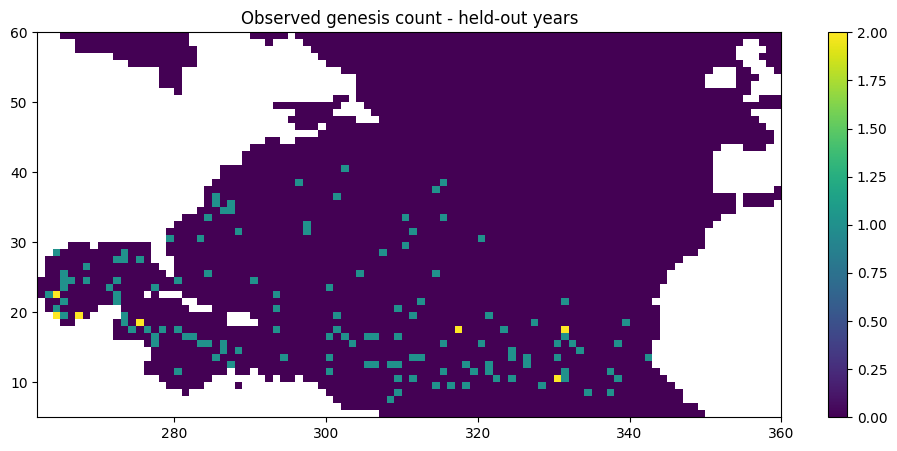

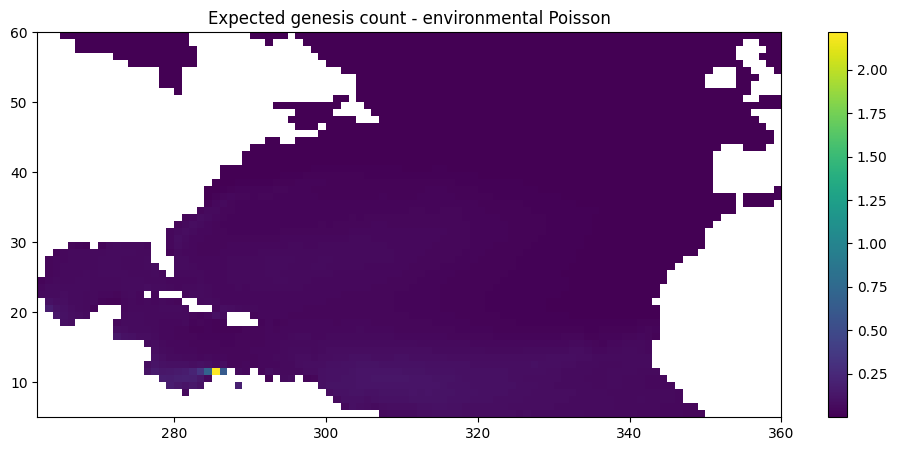

In [153]:
def spatial_summary(df: pd.DataFrame, mu_col: str) -> pd.DataFrame:
    return (
        df.groupby(["latitude", "longitude"], as_index=False)
        .agg(
            observed=("genesis_count", "sum"),
            expected=(mu_col, "sum"),
        )
    )

spatial = spatial_summary(test, "mu_m1")

obs = spatial.pivot(index="latitude", columns="longitude", values="observed")
exp = spatial.pivot(index="latitude", columns="longitude", values="expected")

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(obs.columns, obs.index, obs.values, shading="auto")
ax.set_title("Observed genesis count - held-out years")
plt.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(exp.columns, exp.index, exp.values, shading="auto")
ax.set_title("Expected genesis count - environmental Poisson")
plt.colorbar(im, ax=ax)
plt.show()

## 15. Fit final historical model

Only after the model form has been selected using blocked/rolling validation should the operational model be refit on the full historical period.

Do not use held-out test years to choose predictors and then report the same years as untouched validation.

In [ ]:
# final_scaler = fit_standardizer(model_df, FEATURES)
# final_df = apply_standardizer(model_df, final_scaler)

# _, final_model = fit_poisson_models(final_df)

## 16. Forecast inference from one SEAS5 member/month

Prepare the forecast environment on exactly the same 1° grid and with the same variable definitions as ERA5.

The model produces `mu_cell`, the expected number of genesis events in each eligible cell for that forecast month.

Then:

\[
\Lambda=\sum_i \mu_i,
\qquad
N\sim Pois(\Lambda),
\qquad
p_i=\mu_i/\Lambda.
\]

In [ ]:
def build_forecast_table(
    env_month_1deg: xr.Dataset,
    coarse_exposure: xr.Dataset,
    valid_month: pd.Timestamp,
    cfg: GenesisConfig,
    scaler: dict,
) -> pd.DataFrame:
    df = (
        env_month_1deg[FEATURES]
        .to_dataframe()
        .reset_index()
    )

    exp_df = (
        coarse_exposure[
            ["eligible_area_km2", "eligible_fraction"]
        ]
        .to_dataframe()
        .reset_index()
    )

    df = df.merge(exp_df, on=["lat", "lon"], how="left")

    valid_month = pd.Timestamp(valid_month).to_period("M").to_timestamp()
    df["time"] = valid_month
    df["year"] = valid_month.year
    df["month"] = valid_month.month

    days = valid_month.days_in_month
    df["exposure"] = (
        (df["eligible_area_km2"] / cfg.area_unit_km2)
        * (days / cfg.reference_month_days)
    )

    valid = (
        (df["eligible_fraction"] >= MIN_ELIGIBLE_FRACTION)
        & (df["exposure"] > 0)
        & np.isfinite(df[FEATURES]).all(axis=1)
    )

    df = df.loc[valid].copy()
    df["log_exposure"] = np.log(df["exposure"])
    df = apply_standardizer(df, scaler)
    return df

# forecast_df = build_forecast_table(
#     seas5_member_month_1deg,
#     coarse_exposure,
#     valid_month="2026-08-01",
#     cfg=CFG,
#     scaler=final_scaler,
# )

# forecast_df["mu_cell"] = final_model.predict(
#     forecast_df,
#     offset=forecast_df["log_exposure"],
# )

## 17. Draw the monthly count and 1° genesis cells

This is the single replacement for both the current basin-frequency draw and the GPI/empirical genesis-map draw.

In [ ]:
def sample_genesis_cells(
    forecast_df: pd.DataFrame,
    rng: np.random.Generator,
    mu_col: str = "mu_cell",
) -> tuple[int, pd.DataFrame]:
    mu = np.clip(forecast_df[mu_col].to_numpy(dtype=float), 0, None)
    Lambda = mu.sum()

    if not np.isfinite(Lambda) or Lambda < 0:
        raise ValueError(f"Invalid integrated genesis rate: {Lambda}")

    n = int(rng.poisson(Lambda))
    if n == 0:
        return 0, forecast_df.iloc[0:0].copy()

    p = mu / Lambda
    chosen = rng.choice(len(forecast_df), size=n, replace=True, p=p)

    return n, forecast_df.iloc[chosen].copy().reset_index(drop=True)

# rng = np.random.default_rng(20260923)
# n, selected_cells = sample_genesis_cells(forecast_df, rng)
# print("Simulated genesis count:", n)

## 18. Uniform 0.1° ocean-constrained downscaling within a selected 1° cell

Your proposed simple downscaling is appropriate for V1.

The only change I would insist on is:

**uniform conditional on eligible ocean**, not uniform over the whole 1° square.

Procedure:

1. identify all eligible 0.1° subcells inside the selected 1° cell;
2. choose one with probability proportional to its spherical area;
3. either use its centre as the 0.1° genesis location, or jitter uniformly within the 0.1° cell.

The optional jitter below is truly area-uniform on the sphere by sampling uniformly in `sin(latitude)`.

In [ ]:
def sample_point_in_selected_cell(
    coarse_lat: float,
    coarse_lon: float,
    fine_mask: xr.Dataset,
    cfg: GenesisConfig,
    rng: np.random.Generator,
    jitter_within_fine_cell: bool = False,
) -> tuple[float, float]:
    r = int(round(cfg.coarse_res / cfg.fine_res))

    ilat = int(round((coarse_lat - (cfg.lat_min + cfg.coarse_res / 2)) / cfg.coarse_res))
    ilon = int(round((coarse_lon - (cfg.lon_min + cfg.coarse_res / 2)) / cfg.coarse_res))

    ys = slice(ilat * r, (ilat + 1) * r)
    xs = slice(ilon * r, (ilon + 1) * r)

    eligible = fine_mask["eligible"].values[ys, xs]
    area = fine_mask["fine_area_km2"].values[ys, xs]

    candidates = np.argwhere(eligible)
    if len(candidates) == 0:
        raise RuntimeError(
            f"Selected coarse cell ({coarse_lat}, {coarse_lon}) "
            "contains no eligible fine ocean cells."
        )

    weights = area[eligible].astype(float)
    weights /= weights.sum()

    k = rng.choice(len(candidates), p=weights)
    jy, jx = candidates[k]

    fine_lat_values = fine_mask["fine_lat"].values[ys]
    fine_lon_values = fine_mask["fine_lon"].values[xs]

    lat_c = float(fine_lat_values[jy])
    lon_c = float(fine_lon_values[jx])

    if not jitter_within_fine_cell:
        # Exact 0.1° output on fine-cell centres.
        return lat_c, lon_c

    half = cfg.fine_res / 2

    lat_lo = np.deg2rad(lat_c - half)
    lat_hi = np.deg2rad(lat_c + half)

    # Equal-area latitude draw on a sphere.
    sin_lat = rng.uniform(np.sin(lat_lo), np.sin(lat_hi))
    lat_out = np.rad2deg(np.arcsin(sin_lat))
    lon_out = rng.uniform(lon_c - half, lon_c + half)

    return float(lat_out), float(lon_out)


def downscale_selected_cells(
    selected_cells: pd.DataFrame,
    fine_mask: xr.Dataset,
    cfg: GenesisConfig,
    rng: np.random.Generator,
) -> pd.DataFrame:
    out = selected_cells.copy()
    points = [
        sample_point_in_selected_cell(
            row.lat,
            row.lon,
            fine_mask=fine_mask,
            cfg=cfg,
            rng=rng,
            jitter_within_fine_cell=False,
        )
        for row in out.itertuples()
    ]

    if points:
        out["genesis_lat"] = [p[0] for p in points]
        out["genesis_lon"] = [p[1] for p in points]
    else:
        out["genesis_lat"] = []
        out["genesis_lon"] = []

    return out

# simulated_genesis = downscale_selected_cells(
#     selected_cells,
#     fine_mask,
#     CFG,
#     rng,
# )

## 19. One complete forecast-month simulation function

In [ ]:
def simulate_forecast_month(
    env_month_1deg: xr.Dataset,
    valid_month,
    final_model,
    scaler,
    coarse_exposure: xr.Dataset,
    fine_mask: xr.Dataset,
    cfg: GenesisConfig,
    rng: np.random.Generator,
) -> pd.DataFrame:
    forecast_df = build_forecast_table(
        env_month_1deg=env_month_1deg,
        coarse_exposure=coarse_exposure,
        valid_month=pd.Timestamp(valid_month),
        cfg=cfg,
        scaler=scaler,
    )

    forecast_df["mu_cell"] = final_model.predict(
        forecast_df,
        offset=forecast_df["log_exposure"],
    )

    _, selected = sample_genesis_cells(
        forecast_df,
        rng=rng,
        mu_col="mu_cell",
    )

    return downscale_selected_cells(
        selected,
        fine_mask=fine_mask,
        cfg=cfg,
        rng=rng,
    )

## 20. Sensitivity experiments before accepting the model

The following are more important than adding a complicated spatial random field.

### Resolution
Repeat the complete fit at:

- 0.5°
- 1°
- 2°

and compare held-out:

- basin-month Poisson log score;
- spatial cell log likelihood;
- integrated annual count bias;
- genesis density maps;
- downstream track/landfall differences.

The expectation is that 1° and 2° will often be close. Use the experiment to justify the choice rather than assuming it.

### Environmental specification
Compare at least:

- M0: month only;
- M1: month + PI + RH + VWS + absolute vorticity;
- M2: M1 with saturating/nonlinear vorticity;
- M3: selected GAM/spline effects if M2 leaves strong nonlinear residuals;
- current phase-frequency + GPI-MIX baseline.

### Distribution
Start with Poisson. Escalate only if held-out aggregate counts show persistent conditional overdispersion.

### Validation
Use blocked or rolling years. Never choose the model from random cell-row cross-validation.

## 21. Recommended next notebook

Once this linear Poisson version is stable, the next notebook should answer only one question:

**Do nonlinear environmental response functions materially improve held-out count and spatial-genesis skill?**

That notebook can compare:

- linear GLM;
- capped/saturating vorticity;
- physically motivated transforms;
- GAM splines;
- PI vs relative SST vs ventilated PI.

Do not add clustering, negative-binomial dispersion, climate indices, or a latent process until the basic environmental rate model has been validated.